# Práctica 3 — Parte 1: Selección de datos y acondicionamiento

Dataset: [Country-data (Kaggle)](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

Exploración y preprocesamiento del conjunto elegido para métodos de agrupamiento. Los datos escalados se guardan en `datos/CountryData/` para la **Parte 2**.

## Dependencias

Ejecutar la primera celda de código una vez.

In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "scikit-learn>=1.3",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)

Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración

Rutas desde la carpeta del proyecto (`datos/`).

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_palette("deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def _find_root(rel: str) -> Path:
    c = Path.cwd()
    for base in (c, c.parent):
        if (base / rel).exists():
            return base
    raise FileNotFoundError(f"No se encontró {rel} desde {c}")


ROOT = _find_root("datos/CountryData/Country-data.csv")
DATA_PATH = ROOT / "datos" / "CountryData" / "Country-data.csv"
DICT_PATH = ROOT / "datos" / "CountryData" / "data-dictionary.csv"
PROCESSED_NPZ = ROOT / "datos" / "CountryData" / "country_preprocessed.npz"

FEATURE_COLS = [
    "child_mort",
    "exports",
    "health",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "gdpp",
]

print("Datos:", DATA_PATH.resolve())
print("Salida Parte 2:", PROCESSED_NPZ.resolve())

Datos: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_3\datos\CountryData\Country-data.csv
Salida Parte 2: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_3\datos\CountryData\country_preprocessed.npz


## 2. Datos

In [3]:
df_raw = pd.read_csv(DATA_PATH)
dict_df = pd.read_csv(DICT_PATH)

print("Forma:", df_raw.shape)
print("\nDiccionario de variables:")
display(dict_df)
display(df_raw.head())
df_raw.info()

Forma: (167, 10)

Diccionario de variables:


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [4]:
print("Valores nulos por columna:")
print(df_raw.isnull().sum())
print("\nTipos:")
print(df_raw.dtypes)
print("\nPaíses únicos:", df_raw["country"].nunique())

Valores nulos por columna:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Tipos:
country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Países únicos: 167


## 3. Exploración

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


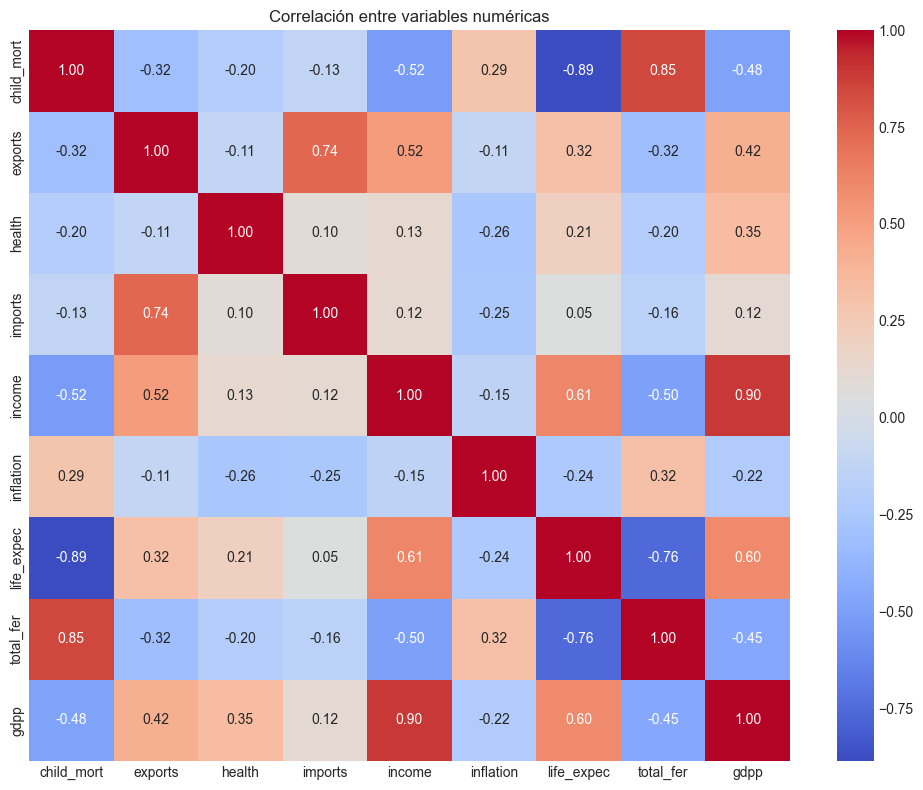

In [5]:
display(df_raw[FEATURE_COLS].describe().T)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_raw[FEATURE_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

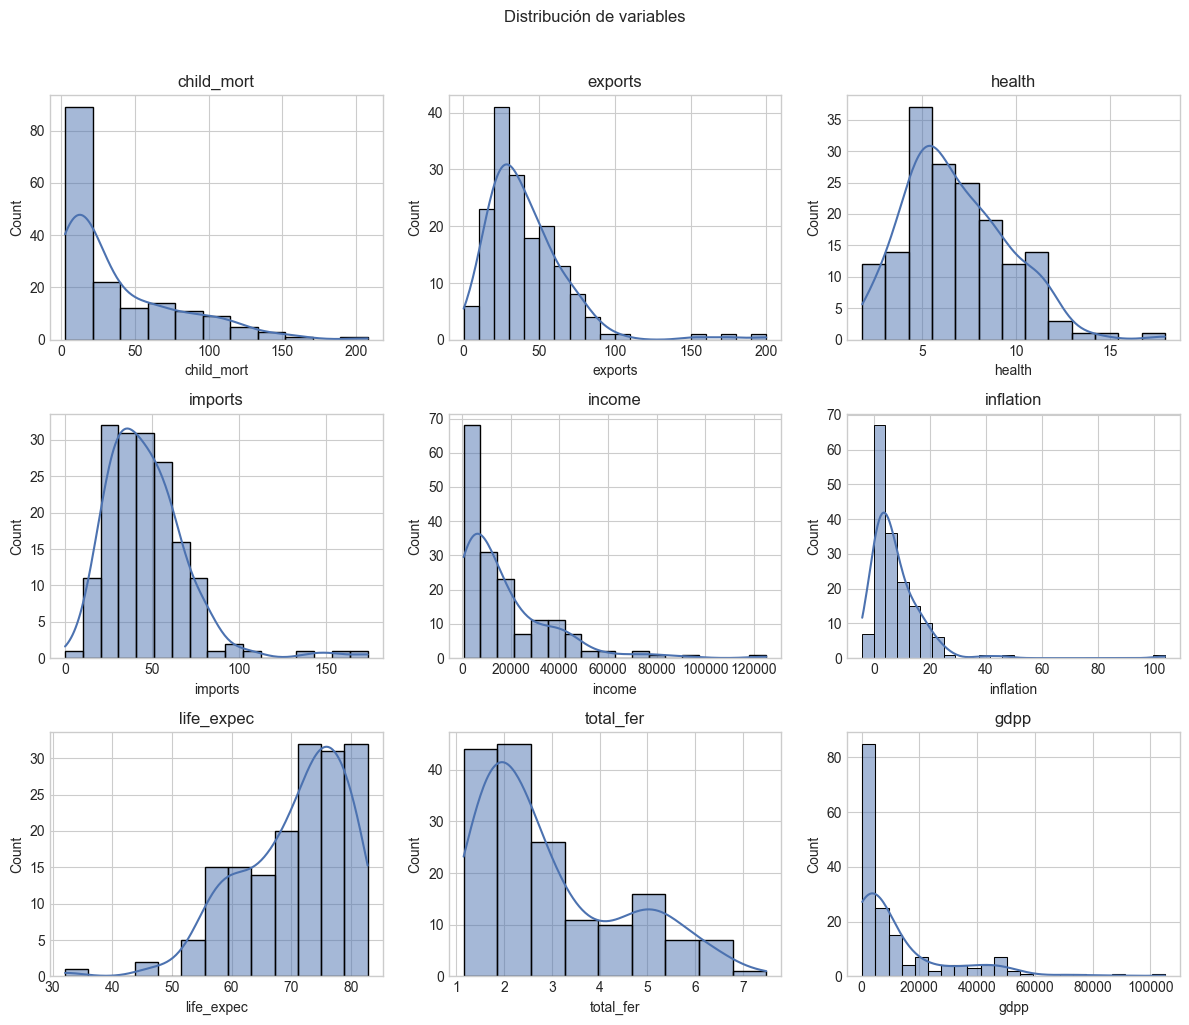

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for ax, col in zip(axes, FEATURE_COLS):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("Distribución de variables", y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

1. **Valores nulos:** el dataset no presenta faltantes; no se aplica imputación.
2. **Variables categóricas:** `country` es identificador; no se codifica para clustering (solo se conserva para etiquetas).
3. **Variables numéricas:** las nueve métricas socioeconómicas ya son numéricas.
4. **Estandarización** con `StandardScaler` para comparar variables en métodos basados en distancias.

Matriz para clustering: (167, 9)
Varianza explicada PCA (2D): 0.631


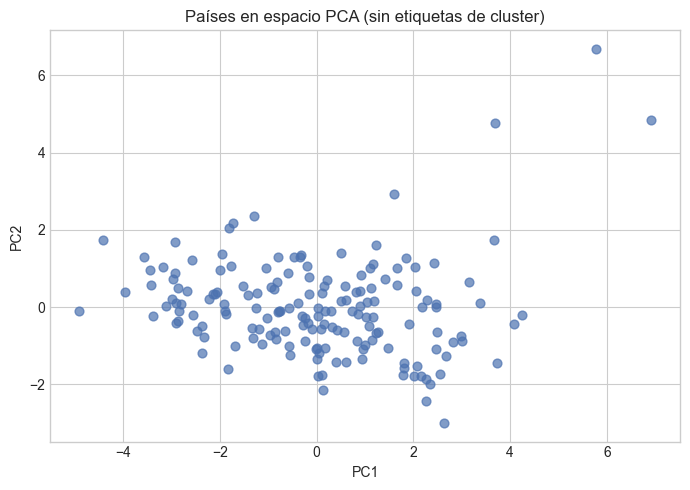

In [7]:
countries = df_raw["country"].copy()
X_df = df_raw[FEATURE_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_vis.fit_transform(X_scaled)

print("Matriz para clustering:", X_scaled.shape)
print("Varianza explicada PCA (2D):", pca_vis.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=40)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Países en espacio PCA (sin etiquetas de cluster)")
plt.tight_layout()
plt.show()

## 5. Guardar datos para la Parte 2

In [8]:
np.savez(
    PROCESSED_NPZ,
    X_scaled=X_scaled,
    X_pca=X_pca,
    countries=countries.to_numpy(),
    feature_cols=np.array(FEATURE_COLS, dtype=object),
    random_state=np.array([RANDOM_STATE]),
)
df_raw.to_csv(ROOT / "datos" / "CountryData" / "country_raw_snapshot.csv", index=False)

scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
scaled_df.insert(0, "country", countries)
scaled_df.to_csv(ROOT / "datos" / "CountryData" / "country_features_scaled.csv", index=False)

print("Guardado:", PROCESSED_NPZ.name)
print("Guardado: country_raw_snapshot.csv, country_features_scaled.csv")

Guardado: country_preprocessed.npz
Guardado: country_raw_snapshot.csv, country_features_scaled.csv


## 6. Resultados

**Resumen.** Country-data: 167 países, 9 variables numéricas + `country`, sin nulos. Tras exploración (asimetrías, correlaciones fuertes como `gdpp`–`income` ≈ 0,90) se aplicó **StandardScaler** → matriz **(167, 9)**. PCA 2D explica **≈ 63 %** de la varianza.

El dataset es **apto para clustering**: completo, sin imputación, y con variables que reflejan desarrollo económico y social. La correlación entre riqueza (`gdpp`, `income`) y salud (`child_mort`, `life_expec`) sugiere que los algoritmos tenderán a separar países pobres, intermedios y ricos. Los **outliers** visibles en PCA (cuadrante alto de PC1/PC2) pueden generar clusters pequeños o puntos de ruido en la Parte 2.

La **estandarización** fue indispensable: sin ella, `income` o `gdpp` pesarían demasiado en la distancia euclídea. Escalar pone las nueve features en pie de igualdad, requisito para K-Means, Ward, DBSCAN y Spectral. El PCA confirma que hay estructura más allá de un único grupo homogéneo.

Se exportaron `country_preprocessed.npz`, `country_raw_snapshot.csv` y `country_features_scaled.csv` en `datos/CountryData/`. El acondicionamiento cumple la guía (nulos, categóricas, preparación numérica) y deja los datos listos para comparar los cuatro métodos de agrupamiento en **Practica3_Parte2_CountryData_Clustering.ipynb**.